In [3]:
# Runtime performance tweaks
import torch
try:
    torch.backends.cudnn.benchmark = True
except Exception:
    pass
try:
    from transformers import enable_gradient_checkpointing
    enable_gradient_checkpointing()
except Exception:
    pass
print('Performance tweaks applied')


Performance tweaks applied


In [3]:
!pip install pandas numpy torch matplotlib seaborn scikit-learn transformers datasets evaluate accelerate openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [5]:
dfa = pd.read_csv(r"C:\\Users\\Abdullah\\Desktop\\Code\\Transfer Learning\\Transfer Learning\\Datasets\\WELFake_Dataset.csv")

In [6]:
dfa.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [7]:
dfa.info()

<class 'pandas.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  72134 non-null  int64
 1   title       71576 non-null  str  
 2   text        72095 non-null  str  
 3   label       72134 non-null  int64
dtypes: int64(2), str(2)
memory usage: 235.0 MB


In [8]:
dfa = dfa[['title', 'text', 'label']]

In [9]:
dfa.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [10]:
dfa.shape

(72134, 3)

In [11]:
dfa.drop_duplicates(inplace=True)

In [12]:
dfa.dropna(inplace=True)

In [13]:
dfa.shape

(63121, 3)

In [13]:
dfa['label'].value_counts()

label
0    34791
1    28330
Name: count, dtype: int64

<Axes: xlabel='label'>

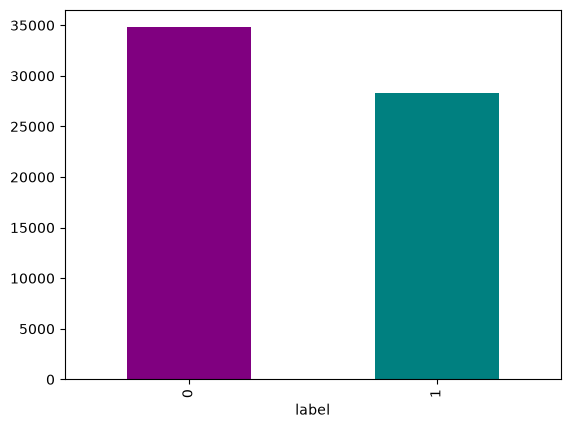

In [15]:
dfa['label'].value_counts().plot(kind='bar', color=['purple', 'teal'])

In [110]:
dba = pd.read_csv(r"C:\\Users\\Abdullah\\Desktop\\Code\\Transfer Learning\\Transfer Learning\\Datasets\\True.csv")
dbb = pd.read_csv(r"C:\\Users\\Abdullah\\Desktop\\Code\\Transfer Learning\\Transfer Learning\\Datasets\\Fake.csv")

In [111]:
dba['label'] = 1
dbb['label'] = 0

In [113]:
dfb = pd.concat([dba, dbb], ignore_index=True)

In [114]:
dfb.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [115]:
dfb.sample(10)

,title,text,subject,date,label
22216,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
27917,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
25007,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
1377,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
32476,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0
5766,"As private lawyer, Trump high court pick was f...",WASHINGTON (Reuters) - As a lawyer in private ...,politicsNews,"February 1, 2017",1
16230,Yemeni Salafist imam killed in Aden: sources,ADEN (Reuters) - A Salafist imam was shot dead...,worldnews,"October 28, 2017",1
20911,FBI says witnesses in U.S. probe into Malaysia...,KUALA LUMPUR (Reuters) - Potential witnesses t...,worldnews,"September 6, 2017",1
35838,An Easy To Read Chart Shows How Bernie Sanders...,The goal of socialism is communism. -Vladimi...,politics,"Feb 24, 2016",0
33155,MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...,Opposing views and beliefs has much of this co...,politics,"Feb 4, 2017",0


In [116]:
dfb = dfb[['title', 'text', 'label']]

In [117]:
dfb.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [118]:
dfb.shape

(44898, 3)

In [119]:
dfb['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

<Axes: xlabel='label'>

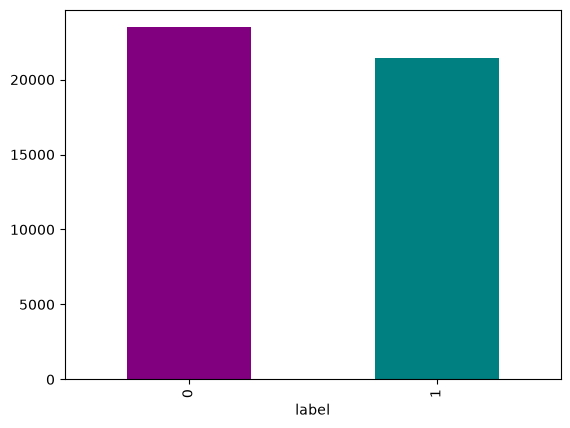

In [120]:
dfb['label'].value_counts().plot(kind='bar', color=['purple', 'teal'])

In [121]:
dfb.drop_duplicates(inplace=True)

In [122]:
dfb.dropna(inplace=True)

In [123]:
dfb.shape

(39105, 3)

In [140]:
dfb = pd.concat([dba, dbb], ignore_index=True)
dfb = dfb[['title', 'text', 'label']]
dfb.drop_duplicates(inplace=True)
dfb.dropna(inplace=True)

dfb = dfb.sample(n=min(20000, len(dfb)), random_state=SEED)

dfb['news'] = dfb['title'].astype(str) + " " + dfb['text'].astype(str).str[:100]

print(f"dfb size after sampling: {len(dfb)}")

dfb size after sampling: 20000


In [141]:
dfb.head()

,title,text,label,news
29270,This Church Treasurer Is Going To Jail For A ...,A church treasurer from Ohio is going to jail ...,0,This Church Treasurer Is Going To Jail For A ...
32383,SENATOR FEINSTEIN Shocks CNN Anchor With “Prec...,"What s all the fuss about if there s no there,...",0,SENATOR FEINSTEIN Shocks CNN Anchor With “Prec...
43768,Hillary Clinton Supporters Now Calling for a R...,The person who received the most votes free f...,0,Hillary Clinton Supporters Now Calling for a R...
8871,U.S. appeals court upholds conviction over sha...,(Reuters) - A divided federal appeals court on...,1,U.S. appeals court upholds conviction over sha...
14359,Kenya's Supreme Court upholds Kenyatta's presi...,NAIROBI (Reuters) - Kenya s Supreme Court on M...,1,Kenya's Supreme Court upholds Kenyatta's presi...


In [142]:
dfb.drop(['title', 'text'], axis=1, inplace=True, errors='ignore')

In [143]:
dfb.head()

,label,news
29270,0,This Church Treasurer Is Going To Jail For A ...
32383,0,SENATOR FEINSTEIN Shocks CNN Anchor With “Prec...
43768,0,Hillary Clinton Supporters Now Calling for a R...
8871,1,U.S. appeals court upholds conviction over sha...
14359,1,Kenya's Supreme Court upholds Kenyatta's presi...


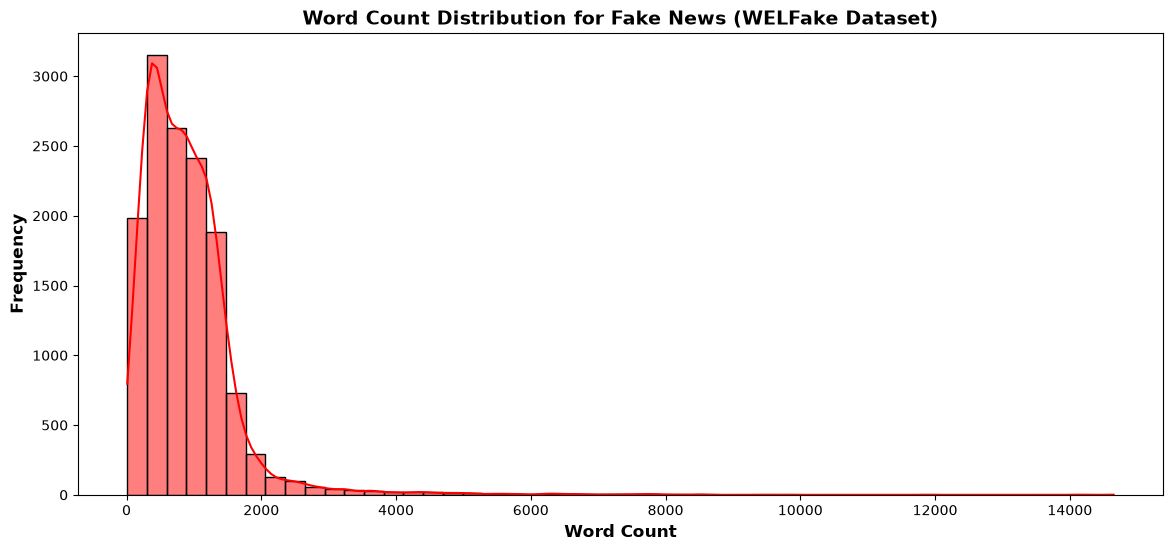

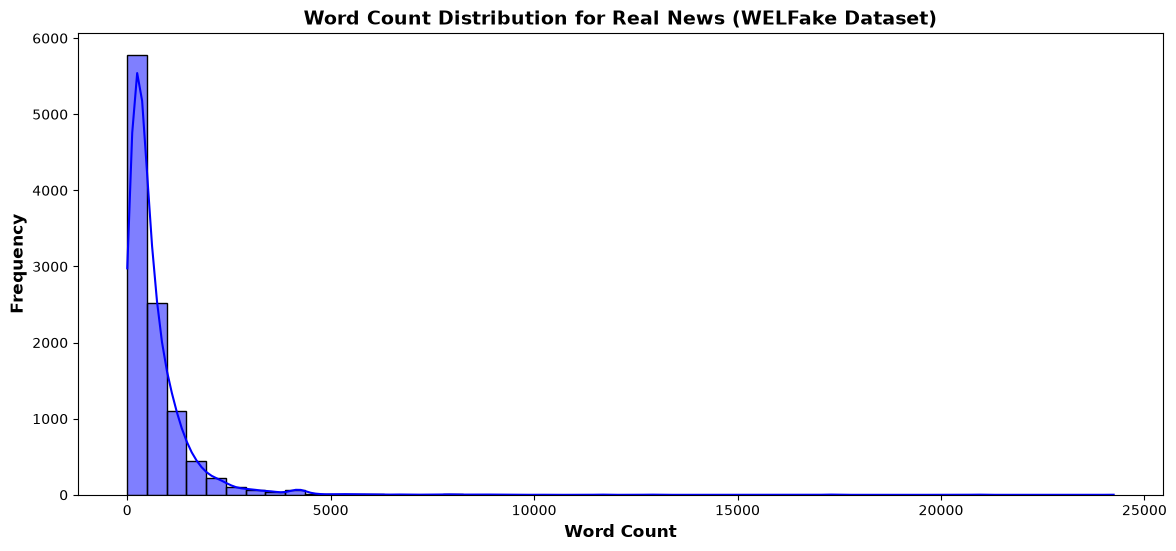

In [63]:
dfa['word_count'] = dfa['news'].astype(str).str.split().str.len()

plt.figure(figsize=(14, 6))
sns.histplot(dfa[dfa['label'] == 0]['word_count'], bins=50, color='red', kde=True)
plt.title('Word Count Distribution for Fake News (WELFake Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

plt.figure(figsize=(14, 6))
sns.histplot(dfa[dfa['label'] == 1]['word_count'], bins=50, color='blue', kde=True)
plt.title('Word Count Distribution for Real News (WELFake Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

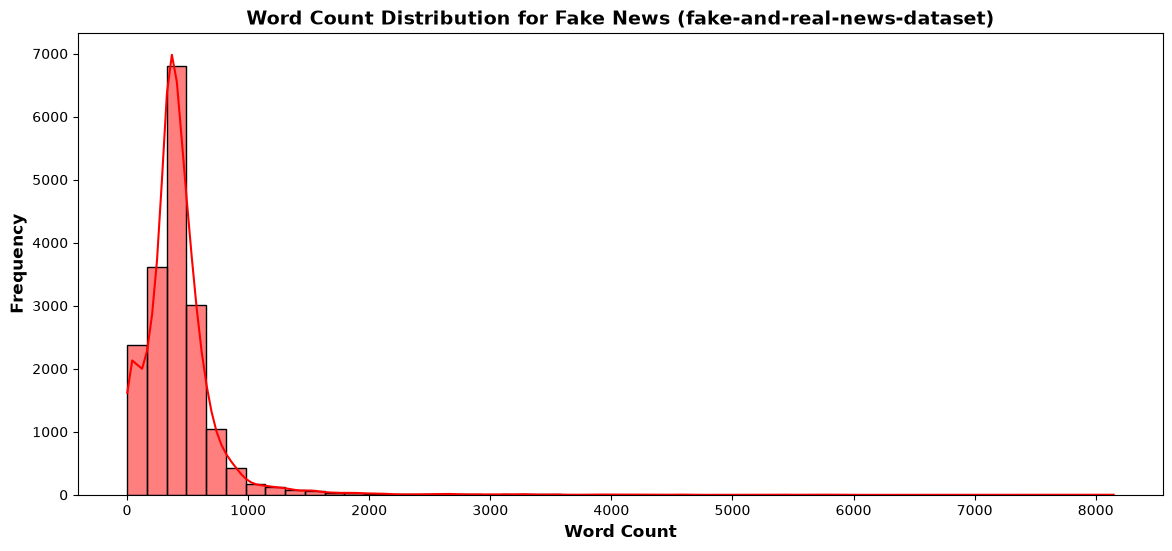

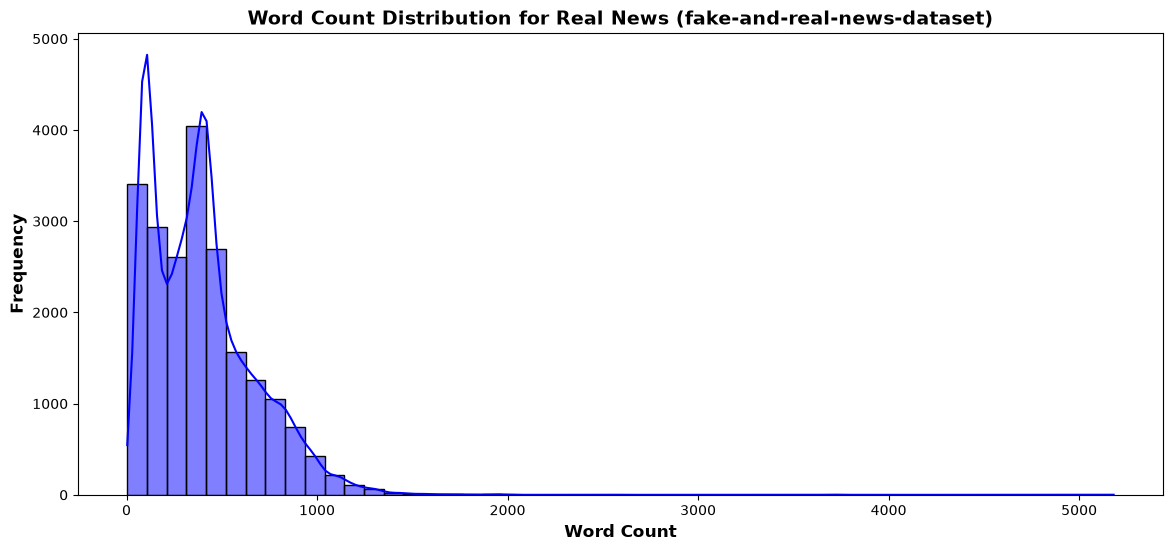

In [84]:
dfb['word_count'] = dfb['news'].astype(str).str.split().str.len()

plt.figure(figsize=(14, 6))
sns.histplot(dfb[dfb['label'] == 0]['word_count'], bins=50, color='red', kde=True)
plt.title('Word Count Distribution for Fake News (fake-and-real-news-dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

plt.figure(figsize=(14, 6))
sns.histplot(dfb[dfb['label'] == 1]['word_count'], bins=50, color='blue', kde=True)
plt.title('Word Count Distribution for Real News (fake-and-real-news-dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

In [65]:
print("Summary statistics for word counts per label:")
display(dfa.groupby('label')['word_count'].describe())

Summary statistics for word counts per label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,13594.0,892.570914,741.508976,11.0,421.25,786.0,1186.0,14650.0
1,10422.0,679.028785,965.889856,2.0,215.00,422.0,831.0,24243.0


In [85]:
print("Summary statistics for word counts per label:")
display(dfb.groupby('label')['word_count'].describe())

Summary statistics for word counts per label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17908.0,429.015077,357.153684,2.0,279.0,385.0,514.0,8148.0
1,21197.0,394.814644,273.772755,4.0,157.0,368.0,533.0,5181.0


In [38]:
modelName = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(modelName)
print("Tokenizer initialized.", modelName)

Tokenizer initialized. xlm-roberta-base


In [86]:
sample_texts = dfa['news'].sample(500, random_state=42).tolist()
lengths = [len(tokenizer(t)['input_ids']) for t in sample_texts]

print(f"Mean:     {np.mean(lengths):.0f}")
print(f"Median:   {np.median(lengths):.0f}")
print(f"90th pct: {np.percentile(lengths, 90):.0f}")
print(f"95th pct: {np.percentile(lengths, 95):.0f}")
print(f"99th pct: {np.percentile(lengths, 99):.0f}")

MAX_LENGTH = 256
print(f"Using MAX_LENGTH = {MAX_LENGTH}")


Mean:     1127
Median:   892
90th pct: 2070
95th pct: 2643
99th pct: 5856
Using MAX_LENGTH = 256


In [87]:
dfb.head()

,label,news,word_count
0,1,"As U.S. budget fight looms, Republicans flip t...",759
1,1,U.S. military to accept transgender recruits o...,633
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,467
3,1,FBI Russia probe helped by Australian diplomat...,385
4,1,Trump wants Postal Service to charge 'much mor...,863


In [41]:
dfb = dfb[['news', 'label']]

In [128]:
dfb.head()

,label,news
0,1,WASHINGTON (Reuters) - The head of a conservat...
1,1,WASHINGTON (Reuters) - Transgender people will...
2,1,WASHINGTON (Reuters) - The special counsel inv...
3,1,WASHINGTON (Reuters) - Trump campaign adviser ...
4,1,SEATTLE/WASHINGTON (Reuters) - President Donal...


In [88]:
sample_texts = dfb['news'].sample(500, random_state=42).tolist()
lengths = [len(tokenizer(t)['input_ids']) for t in sample_texts]

print(f"Mean:     {np.mean(lengths):.0f}")
print(f"Median:   {np.median(lengths):.0f}")
print(f"90th pct: {np.percentile(lengths, 90):.0f}")
print(f"95th pct: {np.percentile(lengths, 95):.0f}")
print(f"99th pct: {np.percentile(lengths, 99):.0f}")

MAX_LENGTH = 256
print(f"Using MAX_LENGTH = {MAX_LENGTH}")


Mean:     558
Median:   520
90th pct: 1025
95th pct: 1270
99th pct: 1765
Using MAX_LENGTH = 256


In [14]:
train_a, test_a = train_test_split(
    dfa,
    test_size=0.2,
    random_state=SEED,
    stratify=dfa['label']
)

print("Train size:", len(train_a))
print("Test size: ", len(test_a))
print("Train label distribution:", train_a['label'].value_counts().to_dict())
print("Test label distribution: ", test_a['label'].value_counts().to_dict())

Train size: 50496
Test size:  12625
Train label distribution: {0: 27832, 1: 22664}
Test label distribution:  {0: 6959, 1: 5666}


In [15]:
def tokenize_fn(examples):
    text_column = 'news' if 'news' in examples else 'text'
    # Convert to strings and handle None values
    texts = [str(t) if t is not None else "" for t in examples[text_column]]
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

In [91]:
dfa.head()

,label,news,word_count,news_norm
3,0,"Bobby Jindal, raised Hindu, uses story of Chri...",1337,"bobby jindal, raised hindu, uses story of chri..."
4,1,SATAN 2: Russia unvelis an image of its terrif...,345,satan 2: russia unvelis an image of its terrif...
9,1,Latest Pipeline Leak Underscores Dangers Of Da...,494,latest pipeline leak underscores dangers of da...
14,0,No Change Expected for ESPN Political Agenda D...,502,no change expected for espn political agenda d...
20,1,America gives Grand Piano to horse Wednesday 9...,241,america gives grand piano to horse wednesday 9...


In [16]:
train_a, test_a = train_test_split(
    dfa,
    test_size=0.2,
    random_state=SEED,
    stratify=dfa['label']
)

print("Train size:", len(train_a))
print("Test size: ", len(test_a))
print("Train label distribution:", train_a['label'].value_counts().to_dict())
print("Test label distribution: ", test_a['label'].value_counts().to_dict())

Train size: 50496
Test size:  12625
Train label distribution: {0: 27832, 1: 22664}
Test label distribution:  {0: 6959, 1: 5666}


In [94]:
from datasets import Dataset

train_ds_a = Dataset.from_pandas(train_a[['news', 'label']].reset_index(drop=True))
test_ds_a  = Dataset.from_pandas(test_a[['news', 'label']].reset_index(drop=True))

train_ds_a = train_ds_a.map(tokenize_fn, batched=True)
test_ds_a  = test_ds_a.map(tokenize_fn, batched=True)

train_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization done")
print("Train:", train_ds_a)
print("Test: ", test_ds_a)

Map:   0%|          | 0/19212 [00:00<?, ? examples/s]

Map:   0%|          | 0/4804 [00:00<?, ? examples/s]

Tokenization done
Train: Dataset({
    features: ['news', 'label', 'input_ids', 'attention_mask'],
    num_rows: 19212
})
Test:  Dataset({
    features: ['news', 'label', 'input_ids', 'attention_mask'],
    num_rows: 4804
})


In [95]:
from evaluate import load as load_metric

accuracy_metric = load_metric("accuracy")
f1_metric       = load_metric("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1":        f1_metric.compute(predictions=predictions, references=labels)["f1"],
    }

In [96]:
from transformers import TrainingArguments

training_args_1 = TrainingArguments(
    output_dir="./exp1_ax_to_grind",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
)


In [97]:
from transformers import AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding

model_1 = AutoModelForSequenceClassification.from_pretrained(
    modelName,
    num_labels=2
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_1 = Trainer(
    model=model_1,
    args=training_args_1,
    train_dataset=train_ds_a,
    eval_dataset=test_ds_a,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_1.train()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.086685,0.062421,0.983555,0.980876
2,0.032497,0.086958,0.983347,0.980516
3,0.012261,0.069380,0.988135,0.986248


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3603, training_loss=0.06325121764708509, metrics={'train_runtime': 1977.7695, 'train_samples_per_second': 29.142, 'train_steps_per_second': 1.822, 'total_flos': 7582334393364480.0, 'train_loss': 0.06325121764708509, 'epoch': 3.0})

In [100]:
results_1 = trainer_1.evaluate(test_ds_a)
print("Experiment 1: In-domain WELFake")   
print(results_1)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.012261,0.069380,3,0.988135,0.986248


Experiment 1: In-domain WELFake
{'eval_loss': 0.06937956809997559, 'eval_accuracy': 0.988134887593672, 'eval_f1': 0.9862484921592279}


In [144]:
print(f"dfb size before split: {len(dfb)}")

train_b, test_b = train_test_split(
    dfb,
    test_size=0.2,
    random_state=SEED,
    stratify=dfb['label']
)

print(f"After train_test_split - Train size: {len(train_b)}, Test size: {len(test_b)}")
print("Train label distribution:", train_b['label'].value_counts().to_dict())
print("Test label distribution: ", test_b['label'].value_counts().to_dict())
print(f"Train NaN in 'news' column: {train_b['news'].isna().sum()}")
print(f"Test NaN in 'news' column: {test_b['news'].isna().sum()}")

dfb size before split: 20000
After train_test_split - Train size: 16000, Test size: 4000
Train label distribution: {1: 8670, 0: 7330}
Test label distribution:  {1: 2167, 0: 1833}
Train NaN in 'news' column: 0
Test NaN in 'news' column: 0


In [145]:
print(f"Before cleaning - Train size: {len(train_b)}, Test size: {len(test_b)}")

train_b_before = len(train_b)
test_b_before = len(test_b)

train_b = train_b.dropna(subset=['news', 'label']).copy()
test_b = test_b.dropna(subset=['news', 'label']).copy()

print(f"Rows dropped from train_b: {train_b_before - len(train_b)}")
print(f"Rows dropped from test_b: {test_b_before - len(test_b)}")

train_b['news'] = train_b['news'].astype(str)
test_b['news'] = test_b['news'].astype(str)

print(f"After cleaning - Train size: {len(train_b)}, Test size: {len(test_b)}")

train_ds_b = Dataset.from_pandas(train_b[['news', 'label']].reset_index(drop=True))
test_ds_b  = Dataset.from_pandas(test_b[['news', 'label']].reset_index(drop=True))

train_ds_b = train_ds_b.map(tokenize_fn, batched=True)
test_ds_b  = test_ds_b.map(tokenize_fn, batched=True)

train_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization done")

Before cleaning - Train size: 16000, Test size: 4000
Rows dropped from train_b: 0
Rows dropped from test_b: 0
After cleaning - Train size: 16000, Test size: 4000


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenization done


In [146]:
from transformers import TrainingArguments

training_args_2 = TrainingArguments(
    output_dir="./fake-and-true-news-dataset",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=200,
    fp16=True,
    dataloader_num_workers=4,
)


In [147]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
print("Data collator initialized.")

Data collator initialized.


In [148]:
from evaluate import load
metric = load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

print("Compute metrics function defined.")

Compute metrics function defined.


Currently Here

In [149]:
from transformers import AutoModelForSequenceClassification, Trainer

model_2 = AutoModelForSequenceClassification.from_pretrained(
    modelName,
    num_labels=2
)
try:
    model_2.gradient_checkpointing_enable()
except Exception:
    pass

trainer_2 = Trainer(
    model=model_2,
    args=training_args_2,
    train_dataset=train_ds_b,
    eval_dataset=test_ds_b,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_2.train()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.000078,0.000512,0.999769
2,0.000028,0.000141,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2000, training_loss=0.014621332041919231, metrics={'train_runtime': 2064.6947, 'train_samples_per_second': 15.499, 'train_steps_per_second': 0.969, 'total_flos': 4209776885760000.0, 'train_loss': 0.014621332041919231, 'epoch': 2.0})

In [150]:
results_2 = trainer_2.evaluate(test_ds_b)
print("fake-and-true-news-dataset evaluation results:")
for k, v in results_2.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Training Loss,Validation Loss,Epoch,F1
0.000028,0.000141,2,1.000000


fake-and-true-news-dataset evaluation results:
  eval_loss: 0.0001
  eval_f1: 1.0000


Testing B on A

In [152]:
full_ds_b = Dataset.from_pandas(dfb[['news', 'label']].reset_index(drop=True))
full_ds_b = full_ds_b.map(tokenize_fn, batched=True)
full_ds_b.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

trainer_exp3 = Trainer(
    model=model_1,
    args=TrainingArguments(output_dir="./exp3", per_device_eval_batch_size=16, seed=SEED),
    compute_metrics=compute_metrics,
)

results_3 = trainer_exp3.evaluate(full_ds_b)
print("Experiment 3: Cross-domain A to B (trained on WELFake, tested on fake-and-true-news-dataset)")
for k, v in results_3.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step,F1
No log,9.106682,0,0.006253


Experiment 3: Cross-domain A to B (trained on WELFake, tested on fake-and-true-news-dataset)
  eval_loss: 9.1067
  eval_f1: 0.0063


Testing A on B

In [153]:
full_ds_a = Dataset.from_pandas(dfa[['news', 'label']].reset_index(drop=True))
full_ds_a = full_ds_a.map(tokenize_fn, batched=True)
full_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

trainer_exp4 = Trainer(
    model=model_2,
    args=TrainingArguments(output_dir="./exp4", per_device_eval_batch_size=16, seed=SEED),
    compute_metrics=compute_metrics,
)

results_4 = trainer_exp4.evaluate(full_ds_a)
print("Experiment 4: Cross-domain B to A (trained on fake-and-true-news-dataset, tested on WELFake)")
for k, v in results_4.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Map:   0%|          | 0/24016 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step,F1
No log,3.918201,0,0.250609


Experiment 4: Cross-domain B to A (trained on fake-and-true-news-dataset, tested on WELFake)
  eval_loss: 3.9182
  eval_f1: 0.2506


In [155]:
import nltk
import string
from nltk.corpus import stopwords

# Download stopwords if not already available
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Remove punctuation and stopwords from text"""
    # Convert to lowercase
    text = str(text).lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

# Apply preprocessing to both datasets
print("Preprocessing dfa...")
dfa['news_clean'] = dfa['news'].apply(preprocess_text)
print("Preprocessing dfb...")
dfb['news_clean'] = dfb['news'].apply(preprocess_text)

print("Preprocessing complete!")
print("Sample of cleaned text from dfa:")
print(dfa['news_clean'].iloc[0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abdullah\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Preprocessing dfa...
Preprocessing dfb...
Preprocessing complete!
Sample of cleaned text from dfa:
bobby jindal raised hindu uses story christian conversion woo evangelicals potential 2016 bid dozen politically active pastors came private dinner friday night hear conversion story unique context pre


In [156]:
train_a_tfidf, test_a_tfidf = train_test_split(dfa, test_size=0.2, random_state=SEED, stratify=dfa['label'])

tfidf_a = TfidfVectorizer(max_features=10000)
X_train_a = tfidf_a.fit_transform(train_a_tfidf['news_clean'])
X_test_a  = tfidf_a.transform(test_a_tfidf['news_clean'])
y_train_a = train_a_tfidf['label']
y_test_a  = test_a_tfidf['label']

lr_a = LogisticRegression(max_iter=1000, random_state=SEED)
lr_a.fit(X_train_a, y_train_a)
lr_a_preds = lr_a.predict(X_test_a)
print("---- TF-IDF + Logistic Regression: Dataset WELFake ----")
print(classification_report(y_test_a, lr_a_preds))

svm_a = SVC(kernel='linear', random_state=SEED)
svm_a.fit(X_train_a, y_train_a)
svm_a_preds = svm_a.predict(X_test_a)
print("---- TF-IDF + SVM: Dataset WELFake ----")
print(classification_report(y_test_a, svm_a_preds))

---- TF-IDF + Logistic Regression: Dataset WELFake ----
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      2719
           1       0.93      0.92      0.93      2085

    accuracy                           0.94      4804
   macro avg       0.94      0.94      0.94      4804
weighted avg       0.94      0.94      0.94      4804

---- TF-IDF + SVM: Dataset WELFake ----
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2719
           1       0.94      0.94      0.94      2085

    accuracy                           0.95      4804
   macro avg       0.95      0.95      0.95      4804
weighted avg       0.95      0.95      0.95      4804



In [157]:
train_b_tfidf, test_b_tfidf = train_test_split(dfb, test_size=0.2, random_state=SEED, stratify=dfb['label'])

tfidf_b = TfidfVectorizer(max_features=10000)
X_train_b = tfidf_b.fit_transform(train_b_tfidf['news_clean'])
X_test_b  = tfidf_b.transform(test_b_tfidf['news_clean'])
y_train_b = train_b_tfidf['label']
y_test_b  = test_b_tfidf['label']

lr_b = LogisticRegression(max_iter=1000, random_state=SEED)
lr_b.fit(X_train_b, y_train_b)
lr_b_preds = lr_b.predict(X_test_b)
print("---- TF-IDF + Logistic Regression: Dataset fake-and-real-news-dataset ----")
print(classification_report(y_test_b, lr_b_preds))

svm_b = SVC(kernel='linear', random_state=SEED)
svm_b.fit(X_train_b, y_train_b)
svm_b_preds = svm_b.predict(X_test_b)
print("---- TF-IDF + SVM: Dataset fake-and-real-news-dataset ----")
print(classification_report(y_test_b, svm_b_preds))

---- TF-IDF + Logistic Regression: Dataset fake-and-real-news-dataset ----
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1833
           1       1.00      1.00      1.00      2167

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

---- TF-IDF + SVM: Dataset fake-and-real-news-dataset ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1833
           1       1.00      1.00      1.00      2167

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



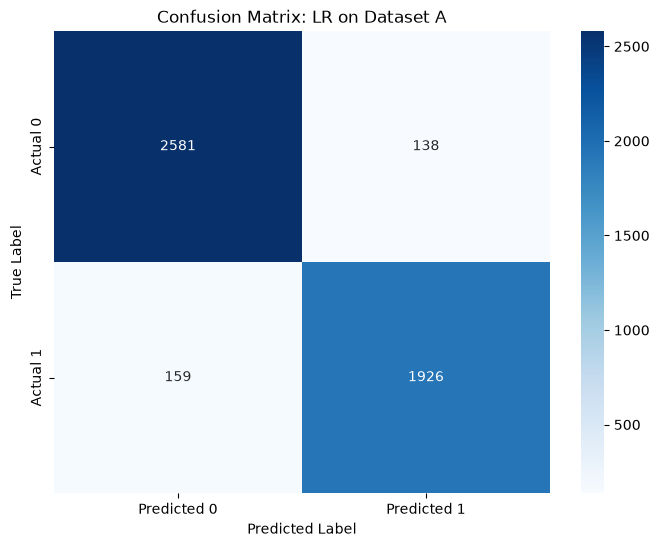

In [158]:
plt.figure(figsize=(8, 6))
cm_lr_a = confusion_matrix(y_test_a, lr_a_preds)
sns.heatmap(cm_lr_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: LR on Dataset A')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

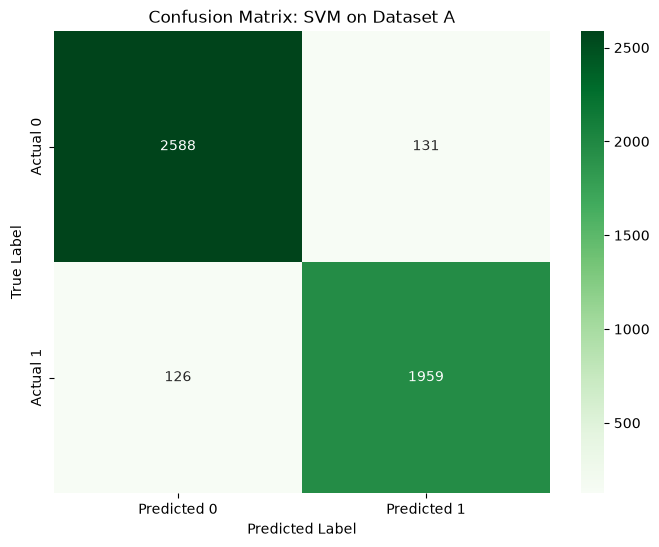

In [159]:
plt.figure(figsize=(8, 6))
cm_svm_a = confusion_matrix(y_test_a, svm_a_preds)
sns.heatmap(cm_svm_a, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: SVM on Dataset A')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

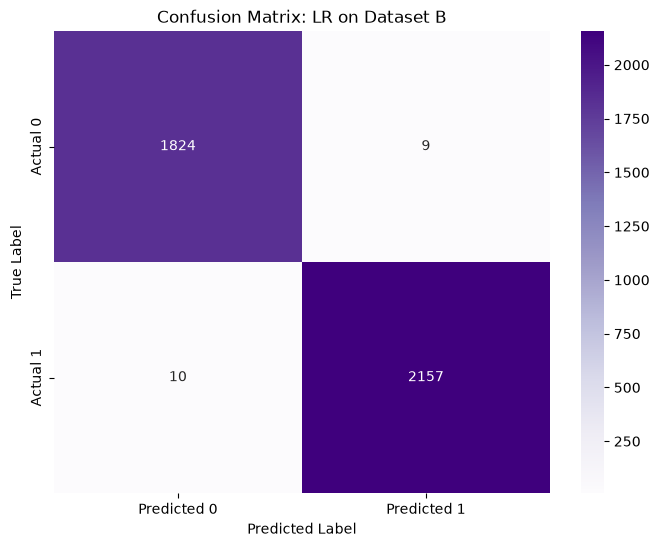

In [160]:
plt.figure(figsize=(8, 6))
cm_lr_b = confusion_matrix(y_test_b, lr_b_preds)
sns.heatmap(cm_lr_b, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: LR on Dataset B')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

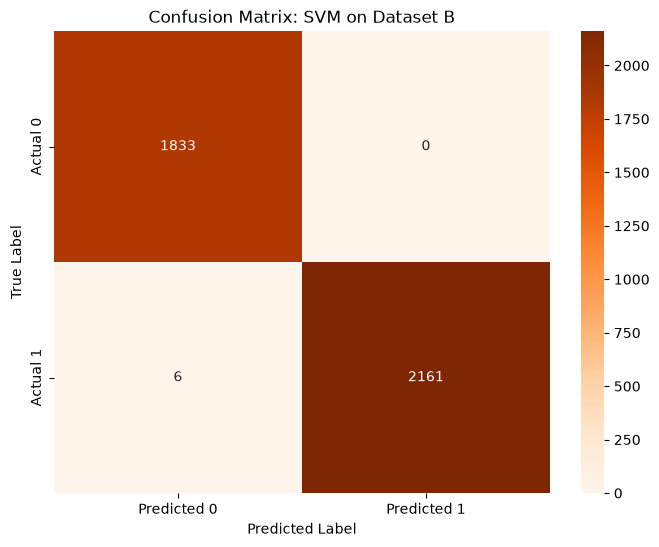

In [161]:
plt.figure(figsize=(8, 6))
cm_svm_b = confusion_matrix(y_test_b, svm_b_preds)
sns.heatmap(cm_svm_b, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: SVM on Dataset B')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [162]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")